In [18]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Function

def preprocessing(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    # gray = cv2.bilateralFilter(gray, 0, 75, 75)
    # gray = cv2.medianBlur(gray, 3)
    gray = cv2.equalizeHist(gray)
    return gray

def init_detector(method):
    if method == 'SIFT':
        return cv2.SIFT_create()
    elif method == 'AKAZE':
        return cv2.AKAZE_create()
    elif method == 'ORB':
        return cv2.ORB_create()
    else:
        print("Method tidak ada!")

def init_flann(method):
    if method == 'SIFT':
        idxparam = dict(algorithm=1, trees=5)
    else:
        idxparam = dict(algorithm=6, table_number=6, key_size=12, multi_prob_level=1)


    srcparam = dict(checks=50)
    return cv2.FlannBasedMatcher(idxparam, srcparam)

In [25]:
# Get Dataset
TARGET_DIR = 'images/target/'
SOURCE_DIR = 'images/source/'
METHODS = ['SIFT','AKAZE','ORB']
LOWE_RATIO = [0.45, 0.5, 0.55]

# get target
target_path = TARGET_DIR + 'hina.png'
target = cv2.imread(target_path)
print("target: ", target.shape)

# get source
source_data = []
for fname in os.listdir(SOURCE_DIR):
    fname = SOURCE_DIR + fname
    fname = cv2.imread(fname)
    source_data.append(fname)

print("Source: ", len(source_data))

target:  (456, 404, 3)
Source:  12


In [ ]:
# pipeline

target_gray = preprocessing(target)

best_matches = 0
best_matches_data = None
best_method = None
best_ratio = None

for method in METHODS:
    print("Method: ", method)

    detector = init_detector(method)
    target_kp, target_desc = detector.detectAndCompute(target_gray, None)
    target_desc = 


Methods:  SIFT
 Lower Ratio:  0.45
     plana.png : 0 good matches
     wakamo.png : 0 good matches
     hoshino.png : 2 good matches
     cherino.png : 1 good matches
     hikari.png : 1 good matches
     hina.png : 36 good matches
     yuuka.png : 0 good matches
     shiroko.png : 0 good matches
     misaki.png : 2 good matches
     miyako.png : 0 good matches
     kisaki.png : 0 good matches
     mika.png : 1 good matches
 Lower Ratio:  0.5
     plana.png : 0 good matches
     wakamo.png : 0 good matches
     hoshino.png : 2 good matches
     cherino.png : 2 good matches
     hikari.png : 1 good matches
     hina.png : 50 good matches
     yuuka.png : 1 good matches
     shiroko.png : 0 good matches
     misaki.png : 2 good matches
     miyako.png : 0 good matches
     kisaki.png : 0 good matches
     mika.png : 1 good matches
 Lower Ratio:  0.55
     plana.png : 0 good matches
     wakamo.png : 0 good matches
     hoshino.png : 3 good matches
     cherino.png : 4 good matches
     

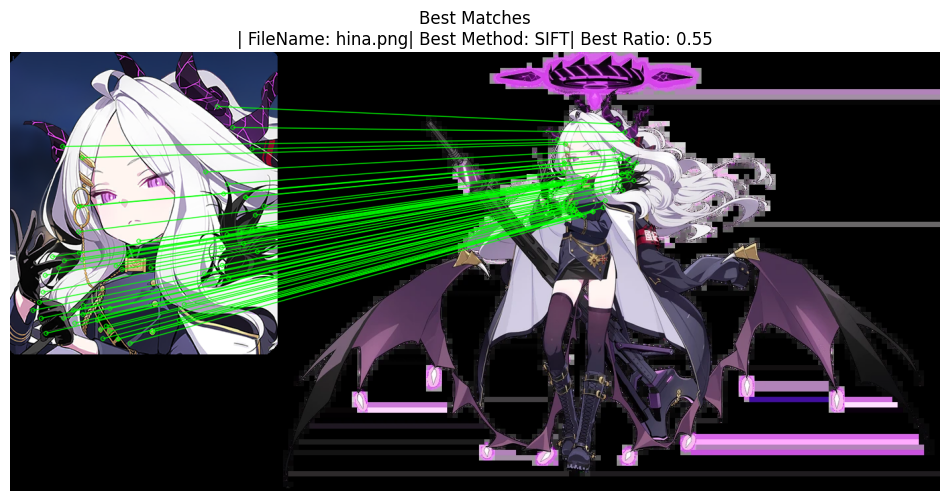


 Best Image:  hina.png
Best Method:  SIFT
Best Ratio:  0.55


In [27]:
# Show Data Image

target_rgb = cv2.cvtColor(target, cv2.COLOR_BGR2RGB)

if best_matches_data is not  None:
    result = cv2.drawMatchesKnn(
        target_rgb,
        best_matches_data['target_kp'],
        best_matches_data['image_data'],
        best_matches_data['keypoint'],
        best_matches_data['match'],
        None,
        matchesMask=best_matches_data['matchesmask'],
        matchColor=[0,255,0],
        flags=cv2.DRAW_MATCHES_FLAGS_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(12,6))
    plt.imshow(result)
    plt.title("Best Matches\n"
              + "| FileName: " + best_matches_data['filename']
              + "| Best Method: " + best_method
              + "| Best Ratio: " + str(best_ratio)
              )
    plt.axis('off')
    plt.show()

    print("\n Best Image: ", best_matches_data['filename'])
    print("Best Method: ", best_method)
    print("Best Ratio: ", best_ratio)
else:
    print("Gada image yang terdeteksi!")
    